# Steel Industry Energy Consumption Exploratory Data Analysis

This notebook performs Exploratory Data Analysis (EDA) on the UCI Steel Industry Energy Consumption dataset. The objective is to understand the distributions of various features, check for data quality issues, and analyze the relationships between energy usage, reactive power, and the target variable (`Load_Type`).

## 1. Import Libraries and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# Load dataset using relative path for local and GitHub compatibility
df = pd.read_csv("Steel_industry_data.csv")

# Clean any extra spaces in column header names
df.columns = df.columns.str.strip().str.replace(' ', '_')

# Parse dates for time-series capabilities
df['date'] = pd.to_datetime(df['date'], format='%d/%m/%Y %H:%M')
df = df.sort_values('date').reset_index(drop=True)

df.head()

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,2018-01-01 00:00:00,3.42,3.46,0.0,0.0,70.30,100.0,0,Weekday,Monday,Light_Load
1,2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
2,2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
3,2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
4,2018-01-01 01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load


## 2. Structural Audit
Let's check the shape, missing values, and data types of the dataset.

In [3]:
print("--- STRUCTURAL AUDIT ---")
print("Dataset Shape (Rows, Columns):", df.shape)
print("\nMissing Values per Column:\n", df.isnull().sum())
print("\nData Types:\n", df.dtypes)

--- STRUCTURAL AUDIT ---
Dataset Shape (Rows, Columns): (35040, 11)

Missing Values per Column:
 date                                    0
Usage_kWh                               0
Lagging_Current_Reactive.Power_kVarh    0
Leading_Current_Reactive_Power_kVarh    0
CO2(tCO2)                               0
Lagging_Current_Power_Factor            0
Leading_Current_Power_Factor            0
NSM                                     0
WeekStatus                              0
Day_of_week                             0
Load_Type                               0
dtype: int64

Data Types:
 date                                    datetime64[us]
Usage_kWh                                      float64
Lagging_Current_Reactive.Power_kVarh           float64
Leading_Current_Reactive_Power_kVarh           float64
CO2(tCO2)                                      float64
Lagging_Current_Power_Factor                   float64
Leading_Current_Power_Factor                   float64
NSM                          

## 3. Data Quality & Sanity Checks
Check for duplicate rows, class imbalance, and overlapping threshold definitions.

In [4]:
print(f"Total Records: {len(df)}")
print(f"Duplicate Rows: {df.duplicated().sum()}")

print("\nClass Distribution of Load_Type:")
print(df['Load_Type'].value_counts(normalize=True).apply(lambda x: f"{x:.2%}"))

# Check for zero energy consumption
zero_usage = df[df['Usage_kWh'] == 0]
print(f"\nRecords with zero Usage_kWh: {len(zero_usage)}")

Total Records: 35040
Duplicate Rows: 0

Class Distribution of Load_Type:
Load_Type
Light_Load      51.58%
Medium_Load     27.67%
Maximum_Load    20.75%
Name: proportion, dtype: str

Records with zero Usage_kWh: 1


## 4. Exploratory Visualizations
Now we'll visualize the data to understand the underlying distributions and relationships.

### 4.1 Target Variable Distribution (`Load_Type`)

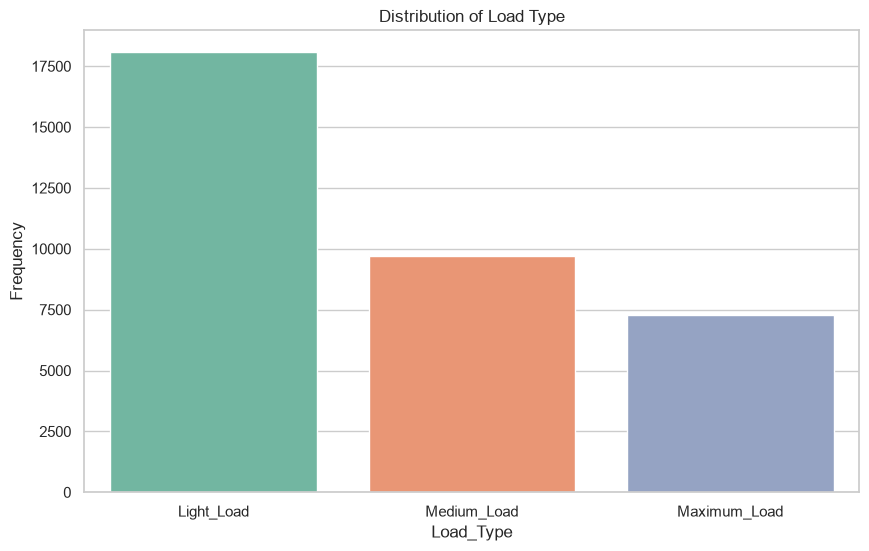

In [5]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Load_Type', data=df, order=['Light_Load', 'Medium_Load', 'Maximum_Load'], palette='Set2')
plt.title('Distribution of Load Type')
plt.ylabel('Frequency')
plt.show()

### 4.2 Feature Relationships (Correlation Heatmap)
We want to see which numeric variables are most strongly correlated with each other.

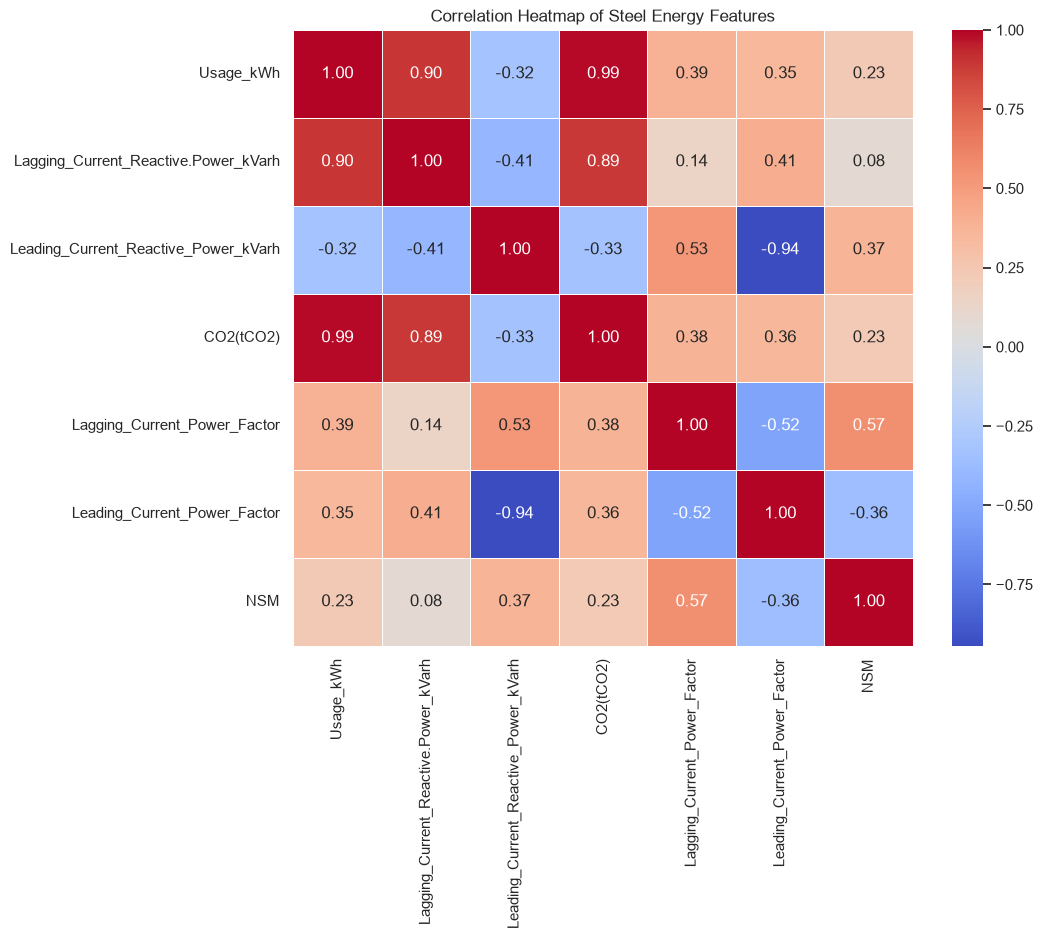

In [6]:
plt.figure(figsize=(10, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Steel Energy Features')
plt.show()

### 4.3 Usage_kWh vs Load Type
Is the Load Type simply a hard threshold of Usage_kWh? Let's check the overlap.

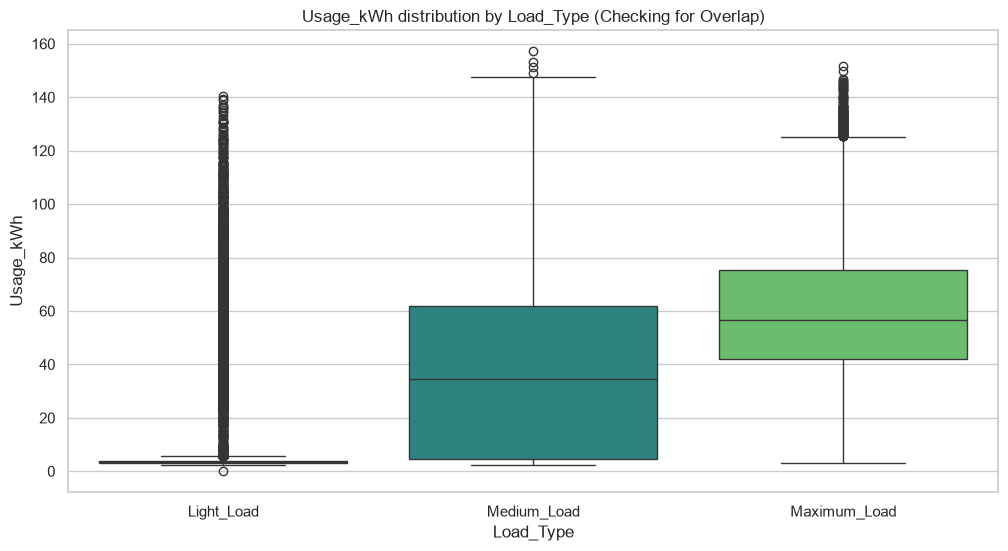

In [7]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Load_Type', y='Usage_kWh', data=df, order=['Light_Load', 'Medium_Load', 'Maximum_Load'], palette='viridis')
plt.title('Usage_kWh distribution by Load_Type (Checking for Overlap)')
plt.show()

### 4.4 Feature Distributions
Check the shape of the data for skewness or anomalies.

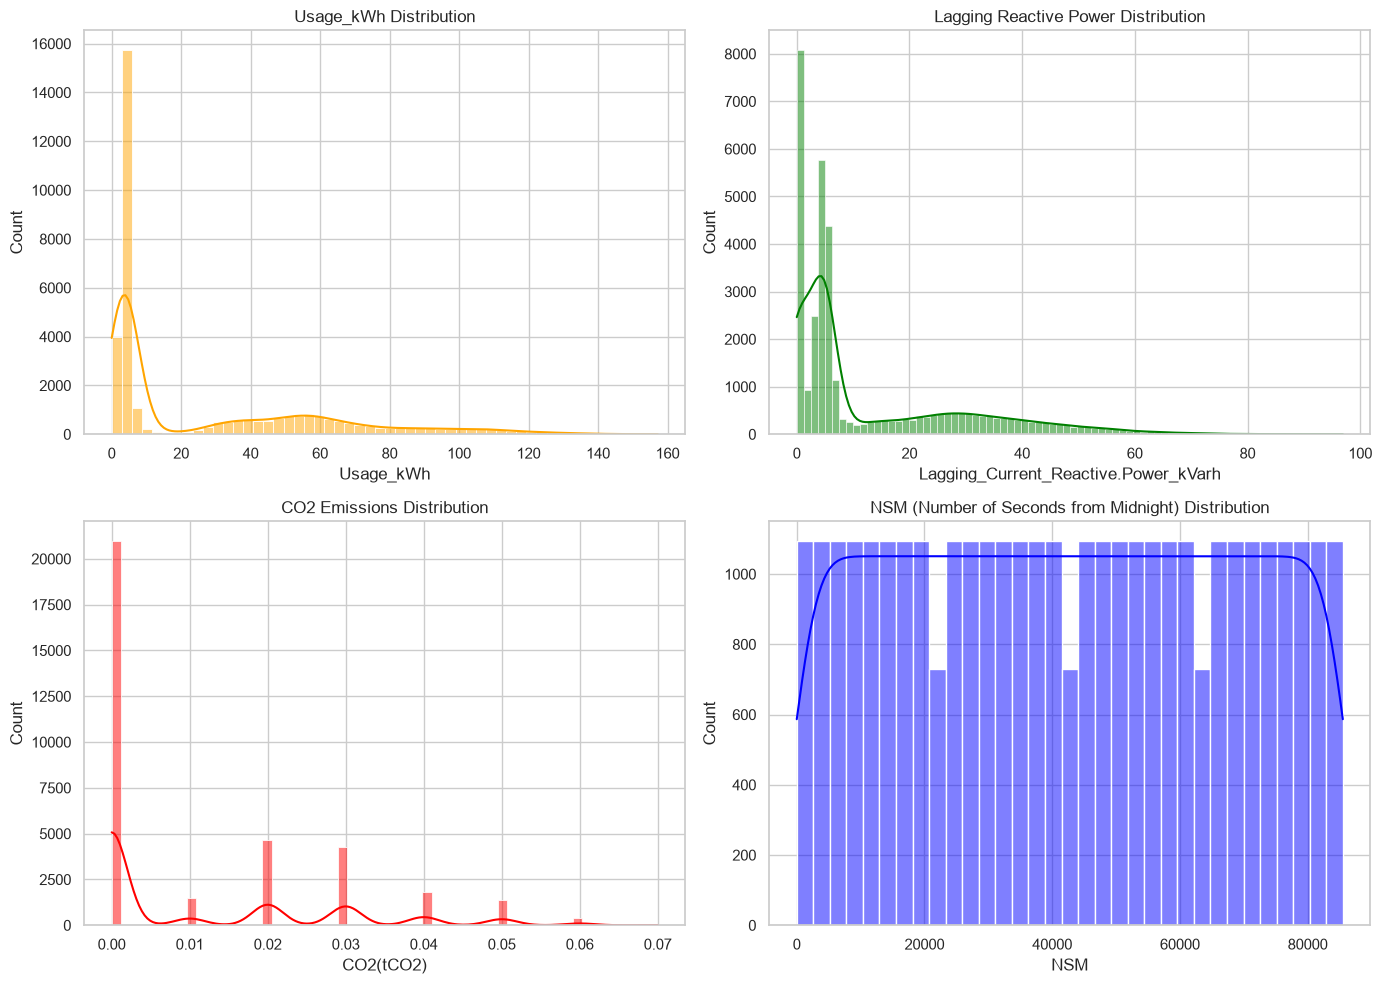

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df['Usage_kWh'], bins='auto', kde=True, ax=axes[0,0], color='orange')
axes[0,0].set_title('Usage_kWh Distribution')

sns.histplot(df['Lagging_Current_Reactive.Power_kVarh'], bins='auto', kde=True, ax=axes[0,1], color='green')
axes[0,1].set_title('Lagging Reactive Power Distribution')

sns.histplot(df['CO2(tCO2)'], bins='auto', kde=True, ax=axes[1,0], color='red')
axes[1,0].set_title('CO2 Emissions Distribution')

sns.histplot(df['NSM'], bins='auto', kde=True, ax=axes[1,1], color='blue')
axes[1,1].set_title('NSM (Number of Seconds from Midnight) Distribution')

plt.tight_layout()
plt.show()

### 4.5 Temporal Patterns (Usage over Time)
Energy usage in industrial settings often follows strong daily and weekly cycles.

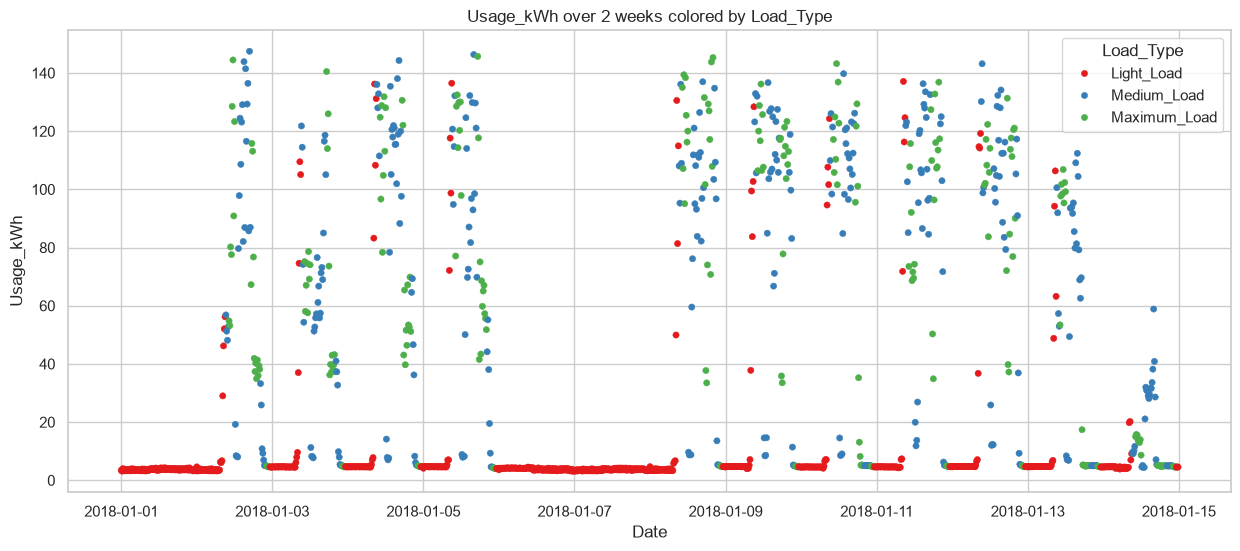

In [9]:
# Plot Usage over time colored by Load Type (sample 2 weeks)
sample_time = df.head(4 * 24 * 14) # 2 weeks of 15-min intervals

plt.figure(figsize=(15, 6))
sns.scatterplot(x='date', y='Usage_kWh', hue='Load_Type', data=sample_time, s=20, edgecolor=None, palette='Set1')
plt.title('Usage_kWh over 2 weeks colored by Load_Type')
plt.xlabel('Date')
plt.ylabel('Usage_kWh')
plt.show()

## 5. Conclusion
- **Data Quality:** The dataset has excellent structural integrity with 0 missing values.
- **Class Imbalance:** `Load_Type` is imbalanced, with `Light_Load` making up over 50% of the dataset.
- **Separability:** `Usage_kWh` overlaps significantly across all three Load Types, meaning Load Type is not a trivial rule-based threshold on energy consumption.
- **Temporal Cycles:** Energy consumption and Load Type are highly dependent on the time of day (`NSM`) and the day of the week, indicating strong seasonality.
- **Modeling Implications:** Due to the strong time-series nature of the data, a random train/test split should be avoided in favor of a chronological split to prevent data leakage.